<a href="https://colab.research.google.com/github/kkumarisfdc/Kiran-s_Portfolio/blob/main/Day_43_Highthrougput_CRISPR_screens.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# =========================================
# Simulating a Pooled CRISPR Screen Analysis
# ==========================================



# =========================================
# Step 1: Install required python packages
# ==========================================

!pip -q install numpy pandas matplotlib seaborn


In [3]:
# =========================================
# Import required libraries
# ==========================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set random seed for reproducibility
np.random.seed(42)

# ---------------------
# Step3: Define genes in the CRISPR library
# --------------------------

genes =[
    "TP53","BRCA1", "EGFR","KRAS","MYC",
    "BRAF","CDK2","CDK4","AKT1","MTOR"
]



In [4]:

# ---------------------
# Step 4: Create four sgRNAs for every gene
# --------------------------
data =[]
for gene in genes:
  for i in range(1,5):
    sgRNA = f"{gene}_sg{i}"
    control = np.random.randint(900,1200)
    treatment = np.random.randint(900,1200)
    data.append([sgRNA,gene,control,treatment])
# ----------------------
# Step 5: Convert into DataFrame
# -------------------------------

df = pd.DataFrame(data,columns=["sgRNA","Gene","control","Treatment"])



In [5]:
# --------------------------------
# Step 6: Simulate essential genes
# --------------------------------

essential_genes =["TP53","BRCA1","CDK2"]
for gene in essential_genes:
  mask = df["Gene"]== gene
  df.loc[mask,"Treatment"]=(
      df.loc[mask,"Treatment"]*0.15
  ).astype(int)

# ----------------------
# Step 7: Display simulated CRISPR count matrix
# -------------------------------

print("\n Sample sgRNA Count Matrix:")
print(df.head())


 Sample sgRNA Count Matrix:
       sgRNA   Gene  control  Treatment
0   TP53_sg1   TP53     1002        175
1   TP53_sg2   TP53     1006        145
2   TP53_sg3   TP53     1088        138
3   TP53_sg4   TP53     1002        153
4  BRCA1_sg1  BRCA1     1114        148


In [7]:
# ====================================
# Save count matrix
# =======================================
df.to_csv("sample_counts.txt", sep="\t",index=False)
print("\n Count matrix saved as sample_counts.txt")


 Count matrix saved as sample_counts.txt


In [9]:
# -----------------------------------------------
# Step 9: Calculate Log2 Fold Change
# Negative values indicate sgRNA depletion
# -----------------------------------------------
df["Log2FC"] = np.log2(
    (df["Treatment"]+1)/(df["control"]+1)
)

# -------------------------------------------------
# Step 10: Calculate average Log2FC for each gene
# Multiple sgRNAs are combined into one gene score
# -------------------------------------------------
gene_scores = (
    df.groupby("Gene")["Log2FC"].mean().reset_index()
)
# -------------------------------------------------
# Step 11: Rank genes
# Lower Log2FC = More likely essential
# -------------------------------------------- ------
gene_scores = gene_scores.sort_values("Log2FC")
print("\nGene Ranking\n")
print(gene_scores)


Gene Ranking

    Gene    Log2FC
9   TP53 -2.742466
2  BRCA1 -2.741329
3   CDK2 -2.612104
7   MTOR -0.043753
4   CDK4 -0.041972
5   EGFR -0.025188
6   KRAS  0.001087
1   BRAF  0.034221
0   AKT1  0.045153
8    MYC  0.072945


In [10]:
# ------------------------------------------------------------------------
# Step 12: Identify top essential genes
# -----------------------------------------------------------------------
top_hits = gene_scores.head(5)
print("\nTop Essential Genes\n")
print(top_hits)


Top Essential Genes

    Gene    Log2FC
9   TP53 -2.742466
2  BRCA1 -2.741329
3   CDK2 -2.612104
7   MTOR -0.043753
4   CDK4 -0.041972


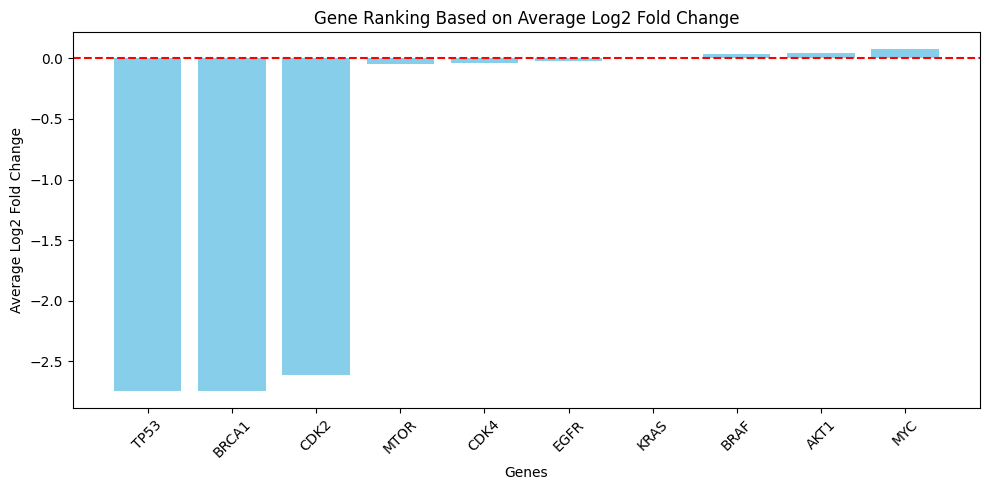

In [11]:
# ----------------------------------------------------------
# Step 13: Plot Gene Ranking
# ---------------------------------------------------------
plt.figure(figsize=(10,5))
plt.bar(
   gene_scores["Gene"],
   gene_scores["Log2FC"],
   color="skyblue"
)
plt.axhline(y=0,color="red",linestyle="--")
plt.xlabel("Genes")
plt.ylabel("Average Log2 Fold Change")
plt.title("Gene Ranking Based on Average Log2 Fold Change")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

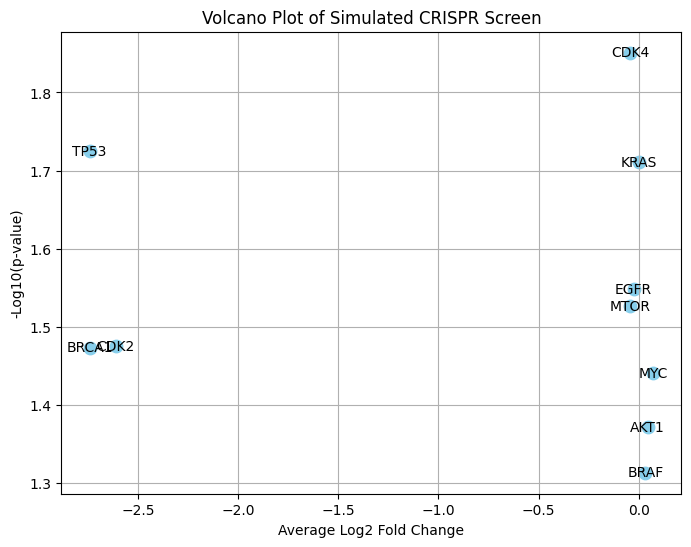

In [13]:
# ------------------------------------------------------------------------------------
# Step 14: Simulate p-values for visualization
# (Educational purpose only)
# -----------------------------------------------------------------------------------
gene_scores["Pvalue"] = np.random.uniform(0.0005,0.05,len(gene_scores))
gene_scores["MinusLog10P"] = -np.log10(gene_scores["Pvalue"])
# -------------------------------------------------------------
# Step 15: Volcano Plot
# -------------------------------------------------------------
plt.figure(figsize=(8,6))
plt.scatter(
    gene_scores["Log2FC"],
    gene_scores["MinusLog10P"],
    color="skyblue",
    s=80
)
# Label each gene
for i,row in gene_scores.iterrows():
  plt.text(
      row["Log2FC"],
      row["MinusLog10P"],
      row["Gene"],
      horizontalalignment="center",
      verticalalignment="center",
      fontsize=10
  )

plt.xlabel("Average Log2 Fold Change")
plt.ylabel("-Log10(p-value)")
plt.title("Volcano Plot of Simulated CRISPR Screen")
plt.grid(True)
plt.show()


In [14]:
# ------------------------------------------------
# Step 16: Highlight predicted essential genes
#--------------------------------------------------
predicted = gene_scores[
    gene_scores["Log2FC"]< -1.5
]
print("\nPredicted Essential Genes\n")
print(predicted)



Predicted Essential Genes

    Gene    Log2FC    Pvalue  MinusLog10P
9   TP53 -2.742466  0.018856     1.724562
2  BRCA1 -2.741329  0.033608     1.473562
3   CDK2 -2.612104  0.033463     1.475433


In [15]:
# --------------------------------------------------------
# Step 17 : Summary
# -------------------------------------------------------
print("\n ===================================================")
print("CRISPR Screen Analysis Complete")
print("====================================================")
print(f"Total Genes Analyzed: {len(gene_scores)}")
print(f"Essential Genes Found: {len(predicted)}")
print("\nPredicted Essential Genes:")
print(predicted["Gene"].tolist())
print("===================================================")


CRISPR Screen Analysis Complete
Total Genes Analyzed: 10
Essential Genes Found: 3

Predicted Essential Genes:
['TP53', 'BRCA1', 'CDK2']


In [ ]:
# ---------------------------------------------------------------
# Step 18: MAGeCK Command (Reference Only)
# Uncomment and run only if MAGeCK is installed
# ----------------------------------------------------------------

# !mageck test \
# -k sample_counts.txt \
# -t Treatment \
# -c Control \
# -n MAGeCK_Output

# --------------------------------------------------------------


In [21]:
%%bash
# -------------------------------------------------
# Step 1: Install Miniconda (skip if already installed)
# -------------------------------------------------
if [ ! -d "/usr/local/miniconda3" ]; then
  wget -q https://repo.anaconda.com/miniconda/Miniconda3-latest-Linux-x86_64.sh
  bash Miniconda3-latest-Linux-x86_64.sh -b -p /usr/local/miniconda
fi
  export PATH=/usr/local/miniconda/bin:$PATH

PREFIX=/usr/local/miniconda
Unpacking bootstrapper...
Unpacking payload...

Installing base environment...

Preparing transaction: ...working... done
Executing transaction: ...working... done
installation finished.
    You currently have a PYTHONPATH environment variable set. This may cause
    unexpected behavior when running the Python interpreter in Miniconda3.
    For best results, please verify that your PYTHONPATH only points to
    directories of packages that are compatible with the Python interpreter
    in Miniconda3: /usr/local/miniconda


In [33]:
# ------------------------------------------------------
# Step 2: Accept Conda Terms of Service
# -----------------------------------------------
import os
os.environ['PATH'] = '/usr/local/miniconda/bin:' + os.environ['PATH']
!conda tos accept --override-channels --channel https://repo.anaconda.com/pkgs/main
!conda tos accept --override-channels --channel https://repo.anaconda.com/pkgs/r

accepted Terms of Service for https://repo.anaconda.com/pkgs/main
accepted Terms of Service for https://repo.anaconda.com/pkgs/r


In [34]:
# -----------------------------------------------
# Step 3: Create Python 3.12 Environment
# -----------------------------------------------
!conda create -y -n mageck_env python=3.12

Jupyter detected...
2 channel Terms of Service accepted
Retrieving notices: - \ | / - \ | / - \ | / - \ | / - \ | / - \ | / - \ | / - done
Channels:
 - defaults
Platform: linux-64
Solving environment: / done


==> WARNING: A newer version of conda exists. <==
    current version: 26.5.3
    latest version: 26.7.0

Please update conda by running

    $ conda self update



## Package Plan ##

  environment location: /usr/local/miniconda/envs/mageck_env

  added / updated specs:
    - python=3.12


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    packaging-26.2             |  py312h06a4308_0         287 KB
    pip-26.1.2                 |     pyhc872135_0         1.1 MB
    python-3.12.13             |       hc5f7cf0_3        30.2 MB
    setuptools-83.0.0          |  py312h06a4308_0         1.6 MB
    wheel-0.47.0               |  

In [37]:
# -----------------------------------------------
# Step 4: Install MAGeCK
# -----------------------------------------------
!conda run -n mageck_env conda install -y \
-c conda-forge \
-c bioconda \
mageck

# -----------------------------------------------
# Step 5: Verify Installation
# -----------------------------------------------

!conda run -n mageck_env mageck --version

Jupyter detected...
2 channel Terms of Service accepted
Channels:
 - conda-forge
 - bioconda
 - defaults
Platform: linux-64
Solving environment: \ | done

# All requested packages already installed.

WARNING conda.conda_pypi.main:notify_externally_managed_future(156): 
  Did you know? You can install many PyPI packages with conda
  using the conda-pypi beta. Get started:
    https://docs.conda.io/projects/conda/en/stable/new-features.html

0.5.9.5


In [38]:
# ---------------------------------------------------
# Step 6: Download MAGeCK source package
# --------------------------------------------------
!wget <MAGeCK_Source_Package_URL> -0 mageck.tar.gz

/bin/bash: line 1: MAGeCK_Source_Package_URL: No such file or directory


### Running MAGeCK Test

Now that MAGeCK is installed in the `mageck_env` conda environment, you can run the `mageck test` command to perform a gene-ranking analysis on your simulated CRISPR screen data. This command will analyze the `sample_counts.txt` file you created earlier.

In [39]:
# --------------------------------------------------------------
# Step 7: Run MAGeCK Test
# --------------------------------------------------------------

# Ensure the PATH is correctly set for the Conda environment
import os
os.environ['PATH'] = '/usr/local/miniconda/envs/mageck_env/bin:' + os.environ['PATH']

# Run the mageck test command within the activated environment
# We specify 'Treatment' as the treatment group and 'control' as the control group.
# The output will be saved with the prefix 'MAGeCK_Output'.
!conda run -n mageck_env mageck test \
  -k sample_counts.txt \
  -t Treatment \
  -c control \
  -n MAGeCK_Output

INFO  @ Thu, 13 Aug 2026 16:40:37: Parameters: /usr/local/miniconda/envs/mageck_env/bin/mageck test -k sample_counts.txt -t Treatment -c control -n MAGeCK_Output 
INFO  @ Thu, 13 Aug 2026 16:40:37: Welcome to MAGeCK v0.5.9.5. Command: test 
INFO  @ Thu, 13 Aug 2026 16:40:37: Loading count table from sample_counts.txt  
INFO  @ Thu, 13 Aug 2026 16:40:37: Processing 1 lines.. 
INFO  @ Thu, 13 Aug 2026 16:40:37: Loaded 40 records. 
INFO  @ Thu, 13 Aug 2026 16:40:37: Loading Rnw template file: /usr/local/miniconda/envs/mageck_env/lib/python3.12/site-packages/mageck/test_report.Rmd. 
INFO  @ Thu, 13 Aug 2026 16:40:37: Loading R template file: /usr/local/miniconda/envs/mageck_env/lib/python3.12/site-packages/mageck/plot_template.RTemplate. 
INFO  @ Thu, 13 Aug 2026 16:40:37: Loading R template file: /usr/local/miniconda/envs/mageck_env/lib/python3.12/site-packages/mageck/plot_template_indvgene.RTemplate. 
INFO  @ Thu, 13 Aug 2026 16:40:37: Loading Rnw template file: /usr/local/miniconda/envs

In [47]:
#--------------------------------
# Step 9: Inspect Dataset
# ---------------------------------
!head sample_counts.txt

sgRNA	Gene	control	Treatment
TP53_sg1	TP53	1002	175
TP53_sg2	TP53	1006	145
TP53_sg3	TP53	1088	138
TP53_sg4	TP53	1002	153
BRCA1_sg1	BRCA1	1114	148
BRCA1_sg2	BRCA1	999	157
BRCA1_sg3	BRCA1	1030	157
BRCA1_sg4	BRCA1	1157	178
EGFR_sg1	EGFR	1091	1176


In [53]:
# ------------------------------------------
# Step 10: Run MAGeCK
# -------------------------------------------
!conda run -n mageck_env mageck test \
-k sample_counts.txt \
-t Treatment \
-c control \
-n demo

INFO  @ Thu, 13 Aug 2026 16:51:26: Parameters: /usr/local/miniconda/envs/mageck_env/bin/mageck test -k sample_counts.txt -t Treatment -c control -n demo 
INFO  @ Thu, 13 Aug 2026 16:51:26: Welcome to MAGeCK v0.5.9.5. Command: test 
INFO  @ Thu, 13 Aug 2026 16:51:26: Loading count table from sample_counts.txt  
INFO  @ Thu, 13 Aug 2026 16:51:26: Processing 1 lines.. 
INFO  @ Thu, 13 Aug 2026 16:51:26: Loaded 40 records. 
INFO  @ Thu, 13 Aug 2026 16:51:26: Loading Rnw template file: /usr/local/miniconda/envs/mageck_env/lib/python3.12/site-packages/mageck/test_report.Rmd. 
INFO  @ Thu, 13 Aug 2026 16:51:26: Loading R template file: /usr/local/miniconda/envs/mageck_env/lib/python3.12/site-packages/mageck/plot_template.RTemplate. 
INFO  @ Thu, 13 Aug 2026 16:51:26: Loading R template file: /usr/local/miniconda/envs/mageck_env/lib/python3.12/site-packages/mageck/plot_template_indvgene.RTemplate. 
INFO  @ Thu, 13 Aug 2026 16:51:26: Loading Rnw template file: /usr/local/miniconda/envs/mageck_e

In [51]:
#---------------------------------------------------------
# Step 11: List Output files
# ---------------------------------------------------------
!ls -lh

total 189M
-rw-r--r-- 1 root root  930 Aug 13 16:48 demo.gene_summary.txt
-rw-r--r-- 1 root root 6.0K Aug 13 16:48 demo.log
-rw-r--r-- 1 root root  33K Aug 13 16:48 demo.R
-rw-r--r-- 1 root root  18K Aug 13 16:48 demo.report.Rmd
-rw-r--r-- 1 root root 4.8K Aug 13 16:48 demo.sgrna_summary.txt
-rw-r--r-- 1 root root  37K Aug 13 16:48 demo_summary.Rnw
-rw-r--r-- 1 root root  930 Aug 13 16:40 MAGeCK_Output.gene_summary.txt
-rw-r--r-- 1 root root 6.0K Aug 13 16:40 MAGeCK_Output.log
-rw-r--r-- 1 root root  33K Aug 13 16:40 MAGeCK_Output.R
-rw-r--r-- 1 root root  18K Aug 13 16:40 MAGeCK_Output.report.Rmd
-rw-r--r-- 1 root root 4.8K Aug 13 16:40 MAGeCK_Output.sgrna_summary.txt
-rw-r--r-- 1 root root  37K Aug 13 16:40 MAGeCK_Output_summary.Rnw
-rw-r--r-- 1 root root 189M Jul 29 23:47 Miniconda3-latest-Linux-x86_64.sh
-rw-r--r-- 1 root root  955 Aug 13 16:00 sample_counts.txt
drwxr-xr-x 1 root root 4.0K Aug 10 13:26 sample_data


In [52]:
#------------------------------------------------------------------------
# Step 12: Expected Outputs
#-----------------------------------------------------------------------
 # demo_gene_summary.txt
 # demo_sgrna_summary.txt
 # demo.log